In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, scipy.io as sio
from scipy.spatial import cKDTree

%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.path as mpath, matplotlib.patheffects as pe
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
plt.rcParams['figure.dpi'] = 110

DATA = Path('/Users/advik/Library/Mobile Documents/com~apple~CloudDocs/Documents/'
            'Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium')
AWS_MAT      = Path.home()/'Downloads'/'Mathieu'/'Data'/'dataAWS.mat'
ANT11        = Path.home()/'DataFiles'/'ANT11_masks.nc'
GROUNDED_NPY = Path.home()/'DataFiles'/'ANT11_grounded_mask.npy'
CORES_CSV    = Path.home()/'DataFiles'/'WaterCoresCoords.csv'

N_POT_RAW, N_EXIST = 5794, 118        # rows as they appear in every *Ye.mat
N_SITES_RAW = N_POT_RAW + N_EXIST     # constant; never reassigned

# (-66.44, 162.50) is the Balleny Islands: one isolated cell 378 km from its
# nearest neighbour. Dropping it takes max spacing from 378 km to 105 km.
EXCLUDE_SITES, EXCLUDE_TOL_KM = [(-66.44, 162.50)], 30.0

# ======================= TOGGLES =======================
ENSEMBLE       = 'MRE'      # 'MRE' (160 members) | 'MME' (1001)
VARIABLE       = 'Temp'
ACCUM_ENSEMBLE = 'MRE'      # accumulation source for R_ICE_CORE = k/A

METRIC_SOURCE        = 'computed'   # 'computed' | 'file'
METRIC_GROUNDED_ONLY = True
METRIC_AREA_WEIGHTED = True

# AWS observation error variance.
#   'constant'    -- R_AWS_CONST everywhere.
#   'per_station' -- triple collocation (station / ERA5 cell mean / RACMO cell
#                    mean, annual 1979-2024, floored at 0.02). No dataset is
#                    treated as truth. Includes point-vs-gridcell
#                    representativeness -- NOT instrument accuracy.
R_AWS_MODE  = 'per_station'   # 'constant' | 'per_station'
R_AWS_CONST = 0.2
R_AWS_NEW   = 0.2             # R for a hypothetical NEW station
R_AWS_VALID = 0.05            # frozen: reproduces the reference table, cell 11
# =======================================================

R_AWS_TC_STATION = {          # station -> R (K^2)      raw TC / ERA5-as-truth
    'FaradayVernadsky': 0.731,   # TC +0.731   direct 0.745
    'Rothera':          0.674,   # TC +0.674   direct 0.614
    'Byrd':             0.363,   # TC +0.363   direct 0.362
    'Halley':           0.350,   # TC +0.350   direct 0.592
    'ScottBase':        0.301,   # TC +0.301   direct 0.410
    'AmundsenScott':    0.295,   # TC +0.295   direct 0.361
    'McMurdo':          0.288,   # TC +0.288   direct 0.327
    'Marambio':         0.228,   # TC +0.228   direct 0.406
    'Vostok':           0.215,   # TC +0.215   direct 0.369
    'DDU':              0.089,   # TC +0.089   direct 0.130
    'Novolazarevskaya': 0.087,   # TC +0.087   direct 0.599
    'Neumayer':         0.054,   # TC +0.054   direct 0.260
    'Bellingshausen':   0.038,   # TC +0.038   direct 0.037
    'Casey':            0.027,   # TC +0.027   direct 0.065
    'Davis':            0.027,   # TC +0.027   direct 0.056
    'Mirny':            0.023,   # TC +0.023   direct 0.052
    'Mawson':           0.020,   # TC +0.011   direct 0.039  (floored)
}
R_AWS_DEFAULT = 0.215

# Ice-core R = k/A. k from 42 replicate core pairs: sigma^2 = 2.202 per mil^2
# measured at A = 88.2 mm/yr.
D18O_TO_T, SIGMA2_D18O, A_CALIB = 2.0, 2.202, 88.2
N_BLOCKS, DEBLOCK_MRE = 4, True

def require(*names):
    """Fail loudly if a cell is run before its dependencies."""
    m = [n for n in names if n not in globals()]
    if m:
        raise RuntimeError(f'run the earlier cells first -- missing {m}')

print('DATA ok:', DATA.exists(), '| AWS ok:', AWS_MAT.exists())
print(f'ENSEMBLE={ENSEMBLE}  ACCUM_ENSEMBLE={ACCUM_ENSEMBLE}  R_AWS_MODE={R_AWS_MODE}')


DATA ok: True | AWS ok: True
ENSEMBLE=MRE  ACCUM_ENSEMBLE=MRE  R_AWS_MODE=per_station


In [2]:
def read_numbers(p):
    o = []
    for t in Path(p).read_text().split():
        try: o.append(float(t))
        except ValueError: pass
    return np.asarray(o, float)

def haversine_km(a, b, c, d, Rk=6371.0088):
    a, b, c, d = map(np.radians, (a, b, c, d))
    h = np.sin((c-a)/2)**2 + np.cos(a)*np.cos(c)*np.sin((d-b)/2)**2
    return 2*Rk*np.arcsin(np.sqrt(np.clip(h, 0, 1)))

def deblock(X, nb=N_BLOCKS):
    """Remove each reanalysis's own mean. The MRE temperature METRIC carries a
    ~40 K ERA5 block offset the ESTIMATES do not: raw MRE J correlates 0.20
    with the spatial mean of its own Ye, and 0.95 once both are deblocked.
    Never applied to MME."""
    X = np.asarray(X, float)
    if X.shape[-1] % nb:
        raise ValueError(X.shape)
    return np.concatenate([b - b.mean(-1, keepdims=True)
                           for b in np.split(X, nb, axis=-1)], axis=-1)

def load_Ye_raw(variable=None, ensemble=None):
    """Full 5912-row estimate matrix from disk. Never sliced here."""
    variable = variable or VARIABLE; ensemble = ensemble or ENSEMBLE
    k = f'{variable}{ensemble}Ye'
    Ye = np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float)
    assert Ye.shape[0] == N_SITES_RAW, Ye.shape
    return deblock(Ye) if (ensemble == 'MRE' and DEBLOCK_MRE) else Ye

def load_file_metric(variable=None, ensemble=None):
    """{ENSEMBLE}{VARIABLE}.mat as shipped -- comparison only. NOT a spatial
    average of the estimates: 6.4 K colder than the land-site mean, corr 0.897,
    and no single CCSM4 cell exceeds 0.892. Member-aligned, so internally
    valid, but its definition is unrecoverable."""
    variable = variable or VARIABLE; ensemble = ensemble or ENSEMBLE
    k = f'{ensemble}{variable}'
    Jf = np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float).ravel()
    return deblock(Jf) if (ensemble == 'MRE' and DEBLOCK_MRE) else Jf

def load_accum_raw(ensemble=None):
    """Site-mean accumulation, full 5912 rows. Follows ACCUM_ENSEMBLE."""
    k = f'Accum{ensemble or ACCUM_ENSEMBLE}Ye'
    return np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float).mean(1)

print('helpers defined (nothing loaded yet)')


helpers defined (nothing loaded yet)


In [3]:
require('DATA', 'haversine_km')
ccsm_lat = np.linspace(-90, 90, 192)
ccsm_lon = np.arange(288) * 1.25

def build_site_coords():
    era = xr.open_dataset(DATA / 'data.nc')
    t2m = era[list(era.data_vars)[0]].values
    tm = np.roll(t2m, 1800, axis=2)
    li = pd.read_csv(DATA / 'latInd.csv').values.ravel().astype(int)
    tr = np.zeros((32, 3600))
    for i, it in enumerate(li):
        tr[i, :] = tm[0, it]
    sec = np.zeros((32, 7200))
    for i in range(32):
        sec[i, :7198] = np.dstack((tr[i, :-1],
                                   tr[i, :-1] + np.diff(tr[i])/2.0)).ravel()
    rg = sec[:, ::25]
    la, lo = [], []
    for i in range(32):
        for j in range(288):
            if rg[i, j] > 0:
                la.append(ccsm_lat[i]); lo.append(ccsm_lon[j])
    return np.array(la), np.array(lo)

site_lat_raw, site_lon_raw = build_site_coords()
assert site_lat_raw.size == N_POT_RAW

drop = np.zeros(N_POT_RAW, bool)
for la, lo in EXCLUDE_SITES:
    drop |= haversine_km(la, np.mod(lo, 360.), site_lat_raw, site_lon_raw) < EXCLUDE_TOL_KM
keep_pot = ~drop
site_lat, site_lon = site_lat_raw[keep_pot], site_lon_raw[keep_pot]
N_POTENTIAL = int(keep_pot.sum())
print(f'excluding site(s) {np.flatnonzero(drop)}: ' + ', '.join(
    f'({site_lat_raw[k]:.2f}, {site_lon_raw[k]:.2f})' for k in np.flatnonzero(drop)))
print(f'N_POTENTIAL {N_POT_RAW} -> {N_POTENTIAL}')

# IceShelfMask.csv is the MOA grounding-line latitude at each of 288 longitudes;
# a site north of it is floating.
gl = pd.read_csv(DATA / 'IceShelfMask.csv')['Mask'].values.astype(float)
is_shelf = site_lat > gl[(np.round(site_lon/1.25).astype(int)) % 288]
grounded = ~is_shelf
wts = np.cos(np.deg2rad(site_lat))
print(f'{N_POTENTIAL} sites: {is_shelf.sum()} shelf, {grounded.sum()} grounded')


excluding site(s) [5777]: (-66.44, 162.50)
N_POTENTIAL 5794 -> 5793
5793 sites: 549 shelf, 5244 grounded


In [4]:
require('site_lat', 'N_POTENTIAL')
# The CCSM4 grid has no basin field, so sample the IMBIE basins and topography
# from the RACMO ANT11 mask at each site (nearest neighbour on the sphere).
# NOTE: never name anything _i / _ii / _ / __ here -- IPython reserves those.
a11 = xr.open_dataset(ANT11)
a11_ice = a11['Icesheet_Only'].values > 0.5
a11_B  = a11['Basins'].values[a11_ice]
a11_T  = a11['Topography'].values[a11_ice]
a11_la = a11['lat'].values[a11_ice]
a11_lo = np.mod(a11['lon'].values, 360.)[a11_ice]
a11_gr = np.load(GROUNDED_NPY)[a11_ice]

def to_xyz(la, lo):
    la, lo = np.radians(la), np.radians(lo)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)

nn_dist, nn_idx = cKDTree(to_xyz(a11_la, a11_lo)).query(to_xyz(site_lat, site_lon))
nn_km = 2*6371.0088*np.arcsin(np.clip(nn_dist/2, 0, 1))
site_basin          = a11_B[nn_idx]
site_grounded_imbie = a11_gr[nn_idx]
site_elev           = a11_T[nn_idx]
too_far             = nn_km > 150

REGIONS = {'EAIS': [2, 4, 5, 7, 9, 12, 13, 14, 15, 17],
           'WAIS': [1, 18, 20, 21, 23],
           'AP':   [24, 25, 27]}
region_mask = {rn: (np.isin(site_basin, ids) & site_grounded_imbie & ~too_far)
               for rn, ids in REGIONS.items()}
print(f'nearest ANT11 cell: median {np.median(nn_km):.1f} km, max {nn_km.max():.0f} km '
      f'({too_far.sum()} site(s) >150 km excluded)')
print(f'site elevation: {site_elev.min():.0f}-{site_elev.max():.0f} m, '
      f'median {np.median(site_elev):.0f} m')

# --- PAGES Ant-2K regions (Stenni et al. 2017), port of regions_Ant2K.m ---
PLATEAU_ALTI, PENI, WED, B_AI = 2000.0, -74.0, 330.0, 67.0
_VIC = """-85 150
-84 150
-83 149
-82 148
-81 147
-80 149
-79 150
-78 150
-77 150
-76 155
-75 160
-74 160
-73 160
-72 160
-71 160
-70 160
-69 160
-68 160
-67 160
-66 160
-65 160
-64 160
-63 160"""
vic_tab = np.array([[float(x) for x in l.split()] for l in _VIC.strip().splitlines()])
vic_ord = np.argsort(vic_tab[:, 0])
lats_v, vlim = vic_tab[vic_ord, 0], vic_tab[vic_ord, 1]

def regions_ant2k(lat, lon, elevi, edml_zero=False):
    """Rules applied in order, later ones overwriting -- as in the MATLAB.
    edml_zero=True reproduces the original's region-0 bug; False is the fix."""
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    elevi = np.asarray(elevi, float); sh = lat.shape
    vlat = lat.ravel(); vlon = np.mod(lon.ravel(), 360.); ve = elevi.ravel()
    reg = np.full(vlat.shape, np.nan)
    vll = np.interp(vlat, lats_v, vlim, left=np.nan, right=np.nan)
    with np.errstate(invalid='ignore'):
        reg[(vlon < 145) & (ve > PLATEAU_ALTI)] = 1
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlon < vll)] = 1
        reg[(vlon >= 145) & (vlon < 350) & (vlat < -84) & (ve >= 0)] = 1
        f = 0. if edml_zero else 1.
        reg[(vlon < 30) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon >= 300) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat > -76) & (ve >= 0)] = 7
        reg[(vlon > 0) & (vlon < B_AI) & (ve < PLATEAU_ALTI)] = 7
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat < -75) & (ve >= 0)] = 3
        reg[(vlon >= 300) & (vlon < WED) & (ve < PLATEAU_ALTI)] = 3
        reg[(vlon >= B_AI) & (vlon < 145) & (ve < PLATEAU_ALTI)] = 2
        reg[(vlon >= 145) & (vlon < 160) & (ve >= 0) & (vlon < vll)
            & (ve < PLATEAU_ALTI) & (vlat > -72)] = 2
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlat < -74) & (vlon > vll)] = 6
        reg[(vlon >= 160) & (vlon < 190) & (ve >= 0) & (vlon > vll)] = 6
        reg[(vlon >= 190) & (vlon < 280) & (vlat > -85) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 300) & (vlat > -85) & (vlat < PENI+.5) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 305) & (vlat > PENI) & (ve >= 0)] = 4
    return reg.reshape(sh)

P2K_NAMES = {1: 'East Antarctic Plateau', 2: 'Wilkes Land Coast',
             3: 'Weddell Sea Coast', 4: 'Antarctic Peninsula', 5: 'WAIS',
             6: 'Victoria Land / Ross Sea', 7: 'Dronning Maud Land Coast'}
site_region = regions_ant2k(site_lat, site_lon, site_elev, edml_zero=False)
p2k_mask = {v: ((site_region == v) & site_grounded_imbie & ~too_far)
            for v in range(1, 8)}
print(f'\n{"region":32s} {"sites":>6s} {"weight":>8s}')
for v, nm in P2K_NAMES.items():
    print(f'{v} {nm:30s} {p2k_mask[v].sum():6d} '
          f'{100*wts[p2k_mask[v]].sum()/wts.sum():7.1f}%')


nearest ANT11 cell: median 4.3 km, max 117 km (0 site(s) >150 km excluded)
site elevation: 5-4072 m, median 2545 m

region                            sites   weight
1 East Antarctic Plateau           3677    52.4%
2 Wilkes Land Coast                 183     6.9%
3 Weddell Sea Coast                 276     4.4%
4 Antarctic Peninsula                70     2.4%
5 WAIS                              771    14.4%
6 Victoria Land / Ross Sea          146     2.8%
7 Dronning Maud Land Coast          157     5.4%


In [5]:
require('site_lat', 'is_shelf')
_aws = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']
rows = []
for n_ in _aws._fieldnames:
    r = getattr(_aws, n_)
    la, lo = float(r.lat), np.mod(float(r.lon), 360.0)
    d = haversine_km(la, lo, site_lat, site_lon); k = int(np.argmin(d))
    rows.append(dict(station=n_, lat=la, lon=lo, site=k, km=d[k],
                     shelf=bool(is_shelf[k])))
aws_map = pd.DataFrame(rows)
AWS_SITES = sorted(set(aws_map.site))
print(f'{len(aws_map)} stations -> {len(AWS_SITES)} cells, '
      f'max offset {aws_map.km.max():.0f} km, {aws_map.shelf.sum()} on shelf cells')
aws_map.round(1)


17 stations -> 16 cells, max offset 125 km, 10 on shelf cells


,station,lat,lon,site,km,shelf
0,FaradayVernadsky,-65.1,295.8,5784,43.9,True
1,Rothera,-67.3,291.9,5743,25.3,True
2,Byrd,-80.0,240.7,3361,43.3,False
3,Marambio,-64.2,303.4,5791,124.9,True
4,Mawson,-67.6,62.9,5615,82.3,False
5,Davis,-68.6,78.0,5622,43.3,False
6,McMurdo,-77.9,166.7,3876,25.2,True
7,DDU,-66.7,140.0,5737,75.9,False
8,Bellingshausen,-62.1,301.4,5792,95.4,True
9,Neumayer,-70.4,351.8,5350,86.3,True


In [6]:
require('site_lat', 'grounded', 'keep_pot')

def build_metric(Ye, mask=None, weights=None):
    """cos(lat)-weighted spatial mean of the estimates over `mask`.

    Verified against exact spherical-band cell areas: identical to 4 decimals
    (235.693 vs 235.686 K, corr 1.00000). Unweighted averaging is NOT
    equivalent (corr 0.961) -- the 288 sites at exactly -90 are the same
    physical point and would otherwise carry 5% of the total weight."""
    Y = Ye[:N_POTENTIAL]
    m = np.ones(N_POTENTIAL, bool) if mask is None else np.asarray(mask, bool)
    if weights is None:
        w = np.cos(np.deg2rad(site_lat)) if METRIC_AREA_WEIGHTED \
            else np.ones(N_POTENTIAL)
    else:
        w = np.asarray(weights, float)
    w = w[m]
    return (Y[m] * w[:, None]).sum(0) / w.sum()

def set_ensemble(ens=None):
    """Rebuild every ensemble-dependent array FROM DISK. Idempotent: it never
    reuses what is in memory, so running it twice changes nothing."""
    global ENSEMBLE, Ye, nM, unbias, J, J_computed, J_file, J0var
    global accum_rate, R_ICE_CORE, metric_mask, ENS_STAMP
    if ens is not None:
        ENSEMBLE = ens
    raw = load_Ye_raw()                                  # always 5912 rows
    Ye  = np.concatenate([raw[:N_POT_RAW][keep_pot], raw[N_POT_RAW:]])
    nM, unbias = Ye.shape[1], 1/(Ye.shape[1] - 1)
    metric_mask = grounded if METRIC_GROUNDED_ONLY else np.ones(N_POTENTIAL, bool)
    J_computed  = build_metric(Ye, mask=metric_mask)
    J_file      = load_file_metric()
    J = J_computed if METRIC_SOURCE == 'computed' else J_file
    J0var = unbias * ((J - J.mean())**2).sum()
    accum_rate = load_accum_raw()[:N_POT_RAW][keep_pot]
    R_ICE_CORE = D18O_TO_T**2 * SIGMA2_D18O * A_CALIB / accum_rate
    ENS_STAMP = (ENSEMBLE, VARIABLE, METRIC_SOURCE, ACCUM_ENSEMBLE, nM, Ye.shape)
    print(f'ENSEMBLE={ENSEMBLE}  VARIABLE={VARIABLE}  METRIC_SOURCE={METRIC_SOURCE}')
    print(f'  Ye {Ye.shape}   nM {nM}   DOF {nM-1}   '
          f'deblock={"on" if ENSEMBLE=="MRE" and DEBLOCK_MRE else "off"}')
    print(f'  J: mean {J.mean():.3f} K   sd {J.std(ddof=1):.4f} K   var {J0var:.5f}')
    print(f'  corr(computed, file) = {np.corrcoef(J_computed, J_file)[0,1]:.4f}')
    print(f'  accum Accum{ACCUM_ENSEMBLE}Ye.mat -> R_ICE_CORE median '
          f'{np.median(R_ICE_CORE):.2f} K^2, range {R_ICE_CORE.min():.2f}'
          f' .. {R_ICE_CORE.max():.1f}')
    return ENS_STAMP

def check_ens():
    """First line of every analysis cell. Turns silent drift into an error."""
    want = (ENSEMBLE, VARIABLE, METRIC_SOURCE, ACCUM_ENSEMBLE, nM, Ye.shape)
    if ENS_STAMP != want:
        raise RuntimeError(f'stale state: arrays built as {ENS_STAMP}, config '
                           f'now says {want}. Re-run set_ensemble().')

set_ensemble()


ENSEMBLE=MRE  VARIABLE=Temp  METRIC_SOURCE=computed
  Ye (5911, 160)   nM 160   DOF 159   deblock=on
  J: mean 0.000 K   sd 0.5642 K   var 0.31829
  corr(computed, file) = 0.9049
  accum AccumMREYe.mat -> R_ICE_CORE median 9.70 K^2, range 0.32 .. 47.9


('MRE', 'Temp', 'computed', 'MRE', 160, (5911, 160))

In [7]:
TINY = 1e-12

def variance_reduction(Jdev, Ydev, Rvar, unb):
    den = unb * (Ydev**2).sum(1) + Rvar
    num = (unb * (Ydev @ Jdev))**2
    return np.where(den > TINY, num / np.where(den > TINY, den, 1.0), 0.0)

def adjusted_gain(Kn, Kd, Rb):
    ks = np.sqrt(Kd); return Kn / ks / (ks + np.sqrt(Rb))

class OptimalSensor:
    """DASH @optimalSensor (Comboul et al. 2015)."""
    def __init__(self, J, Ye, R):
        J = np.asarray(J, float).ravel()
        self.nM = J.size; self.unbias = 1/(self.nM - 1)
        self.Jdev = J - J.mean()
        Ye = np.asarray(Ye, float)
        self.Ydev = Ye - Ye.mean(1, keepdims=True)
        self.R = (np.full(Ye.shape[0], float(R)) if np.isscalar(R)
                  else np.asarray(R, float).ravel().copy())
        self.J0var = self.metric_variance()

    def metric_variance(self):
        return self.unbias * (self.Jdev**2).sum()

    def evaluate(self):
        return variance_reduction(self.Jdev, self.Ydev, self.R, self.unbias)

    def assimilate(self, i, Rval=None):
        Yb = self.Ydev[i].copy()
        Rb = self.R[i] if Rval is None else Rval
        Yv = self.unbias * (Yb**2).sum()
        if Yv + Rb <= TINY:
            self.Ydev[i] = np.nan
            return self.metric_variance()
        Ka = adjusted_gain(self.unbias * (self.Jdev @ Yb), Yv + Rb, Rb)
        self.Jdev = self.Jdev - Ka*Yb
        self.Ydev = self.Ydev - Ka*Yb
        self.Ydev[i] = np.nan
        return self.metric_variance()

    def run(self, N, exclude=None, min_sep_km=0.0, verbose=True):
        st, vs = [], []
        banned = np.zeros(self.Ydev.shape[0], bool)
        if exclude is not None:
            banned |= np.asarray(exclude, bool)
        for s_ in range(N):
            dv = self.evaluate()
            dv = np.where(np.isfinite(dv), dv, -np.inf); dv[banned] = -np.inf
            for k in st: dv[k] = -np.inf
            b = int(np.argmax(dv)); v = self.assimilate(b)
            if min_sep_km > 0:
                banned |= haversine_km(site_lat[b], site_lon[b],
                                       site_lat, site_lon) < min_sep_km
            st.append(b); vs.append(v)
            if verbose:
                print(f'  {s_+1:3d} site {b:5d} ({site_lat[b]:7.2f}, {site_lon[b]:7.2f})  '
                      f'cumulative {100*(1-v/self.J0var):5.1f}%')
        return np.array(st), np.array(vs)

print('OptimalSensor defined')


OptimalSensor defined


In [8]:
require('aws_map', 'AWS_SITES')

def build_R_aws():
    """R_aws(site) -> observation error variance for that AWS cell.
    Two stations sharing a CCSM4 cell (McMurdo/Scott Base) are averaged."""
    t = aws_map.assign(R=aws_map.station.map(R_AWS_TC_STATION))
    site_R = {int(k): float(v) for k, v in
              t.dropna(subset=['R']).groupby('site').R.mean().items()}
    if R_AWS_MODE == 'per_station':
        f = lambda i: site_R.get(int(i), R_AWS_DEFAULT)
    elif R_AWS_MODE == 'constant':
        f = lambda i: R_AWS_CONST
    else:
        raise ValueError(R_AWS_MODE)
    return f, site_R

R_aws, R_AWS_SITE = build_R_aws()
print(f'R_AWS_MODE = {R_AWS_MODE}' +
      (f'   R = {R_AWS_CONST} for all {len(AWS_SITES)} cells'
       if R_AWS_MODE == 'constant' else
       f'   {len(R_AWS_SITE)}/{len(AWS_SITES)} cells from the TC table'))
print(pd.DataFrame({'station': aws_map.station, 'site': aws_map.site,
                    'R': [R_aws(s) for s in aws_map.site]})
      .sort_values('R', ascending=False).round(3).to_string(index=False))


R_AWS_MODE = per_station   16/16 cells from the TC table
         station  site     R
FaradayVernadsky  5784 0.731
         Rothera  5743 0.674
            Byrd  3361 0.363
          Halley  4441 0.350
   AmundsenScott     0 0.295
       ScottBase  3876 0.294
         McMurdo  3876 0.294
        Marambio  5791 0.228
          Vostok  3542 0.215
             DDU  5737 0.089
Novolazarevskaya  5366 0.087
        Neumayer  5350 0.054
  Bellingshausen  5792 0.038
           Davis  5622 0.027
           Casey  5766 0.027
           Mirny  5756 0.023
          Mawson  5615 0.020


In [9]:
require('site_lat')
cc = pd.read_csv(CORES_CSV, header=None, names=['name', 'alt', 'lat', 'lon'])
cc['lat'] = cc.lat.astype(float)
cc['lon'] = np.mod(cc.lon.astype(float), 360.)
_d = np.array([haversine_km(a, b, site_lat, site_lon) for a, b in zip(cc.lat, cc.lon)])
cc['site'] = _d.argmin(1); cc['km'] = _d.min(1)
CORE_SITES = sorted(set(cc.site))
core_mask = np.zeros(N_POTENTIAL, bool); core_mask[CORE_SITES] = True
name_of = {}
for s_, n_ in zip(cc.site, cc.name):
    name_of.setdefault(int(s_), n_)
print(f'{len(cc)} existing cores -> {len(CORE_SITES)} unique cells '
      f'(median offset {cc.km.median():.0f} km)')


80 existing cores -> 63 unique cells (median offset 27 km)


In [10]:
check_ens()
_ky, _kj = f'{VARIABLE}{ENSEMBLE}Ye', f'{ENSEMBLE}{VARIABLE}'
Ye_raw = np.asarray(sio.loadmat(DATA / f'{_ky}.mat')[_ky], float)
J_raw  = np.asarray(sio.loadmat(DATA / f'{_kj}.mat')[_kj], float).ravel()
tgt    = read_numbers(DATA / f'BS_{ENSEMBLE}_{VARIABLE.lower()}_accumR.csv')
dv_chk = OptimalSensor(J_raw, Ye_raw[:N_POT_RAW],
                       read_numbers(DATA / 'RSheet.csv')[:N_POT_RAW]).evaluate()
corr = np.corrcoef(dv_chk, tgt)[0, 1]
rel  = np.max(np.abs(dv_chk - tgt) / np.maximum(np.abs(tgt), 1e-30))
print(f'algorithm check: 1 - corr {1-corr:.3e}   max rel err {rel:.3e}  '
      f'(CSV precision floor ~5e-5)')
assert corr > 1 - 1e-8 and rel < 1e-3, 'does not match MATLAB'
print('matches the MATLAB output to the precision of the reference file')


algorithm check: 1 - corr 1.289e-10   max rel err 4.894e-05  (CSV precision floor ~5e-5)
matches the MATLAB output to the precision of the reference file


In [11]:
check_ens(); require('p2k_mask', 'AWS_SITES')
rows = []
for lbl, Jm in ([('AIS-wide', J)] +
                [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]))
                 for v in range(1, 8)]):
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_AWS_VALID)          # FROZEN, not R_aws
    v0m = ob.metric_variance()
    rows.append(dict(metric=lbl, var=J0m, sd=np.sqrt(J0m), remaining=v0m,
                     resid_sd=np.sqrt(v0m), constrained_pct=100*(1 - v0m/J0m)))
REG = pd.DataFrame(rows)
print(f'FROZEN VALIDATION at R = {R_AWS_VALID}, {nM} members\n')
print(REG.round(4).to_string(index=False))
REF = [92.4395, 92.0159, 92.8527, 58.5090, 80.6740, 85.8140, 78.9853, 89.0512]
ok = np.allclose(REG.constrained_pct.values, REF, atol=1e-3)
print(f'\nregression vs reference: {"PASS" if ok else "FAIL"}')
assert ok, 'notebook no longer reproduces the reference table'


FROZEN VALIDATION at R = 0.05, 160 members

                     metric    var     sd  remaining  resid_sd  constrained_pct
                   AIS-wide 0.3183 0.5642     0.0241    0.1551          92.4395
  1. East Antarctic Plateau 0.4244 0.6514     0.0339    0.1841          92.0159
       2. Wilkes Land Coast 0.4651 0.6820     0.0332    0.1823          92.8527
       3. Weddell Sea Coast 0.6036 0.7769     0.2504    0.5004          58.5090
     4. Antarctic Peninsula 0.7379 0.8590     0.1426    0.3776          80.6740
                    5. WAIS 0.5494 0.7412     0.0779    0.2792          85.8140
6. Victoria Land / Ross Sea 0.4917 0.7012     0.1033    0.3214          78.9853
7. Dronning Maud Land Coast 0.3197 0.5655     0.0350    0.1871          89.0512

regression vs reference: PASS


In [12]:
check_ens(); require('site_lat', 'aws_map')
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
CMAP = plt.cm.Greens

# The sites lie exactly on the CCSM4 grid, so map them back onto it rather
# than interpolating: 32 southern latitude rows x 288 longitudes.
LAT32 = ccsm_lat[:32]
_gi = np.searchsorted(LAT32, site_lat)
_gj = (np.round(site_lon/1.25).astype(int)) % 288
assert np.allclose(LAT32[_gi], site_lat) and np.allclose(ccsm_lon[_gj], site_lon), \
    'grid index mapping is wrong'
_dlat = np.diff(LAT32).mean()
LAT_E = np.concatenate([LAT32 - _dlat/2, [LAT32[-1] + _dlat/2]])
LON_E = np.concatenate([ccsm_lon - 0.625, [ccsm_lon[-1] + 0.625]])

def to_grid(v):
    v = np.asarray(v, float)
    if v.size != N_POTENTIAL:
        raise ValueError(f'expected {N_POTENTIAL} values, got {v.size} -- '
                         'this array is not a per-site field')
    g = np.full((32, 288), np.nan); g[_gi, _gj] = v
    return g

def polar_ax(ax):
    ax.set_extent([-180, 180, -90, -60], PL)
    th = np.linspace(0, 2*np.pi, 200)
    ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                    transform=ax.transAxes)
    ax.gridlines(linewidth=.3, color='0.7'); ax.coastlines(linewidth=.7)

def field_map(pct, title, ax=None, fig=None, vmax=None, show_aws=False,
              cb=True, fs=12):
    if ax is None:
        fig = plt.figure(figsize=(11, 10)); ax = plt.axes(projection=SP)
    polar_ax(ax)
    vmax = float(np.nanmax(pct)) if vmax is None else vmax
    sc = ax.pcolormesh(LON_E, LAT_E, np.ma.masked_invalid(to_grid(pct)),
                       cmap=CMAP, vmin=0, vmax=vmax, transform=PL, zorder=1,
                       shading='flat')
    if show_aws:
        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=55, c='red',
                   edgecolors='k', lw=.5, transform=PL, zorder=3)
    if cb:
        c = fig.colorbar(sc, ax=ax, shrink=.62, pad=.04)
        c.set_label('% of total variance constrained')
    ax.set_title(title, fontsize=fs)
    return sc

print('plot helpers ready')


plot helpers ready


blank slate: best single core 28.30% of TOTAL variance at (-66.44, 113.75), A = 1666 mm/yr, R = 0.47 K^2


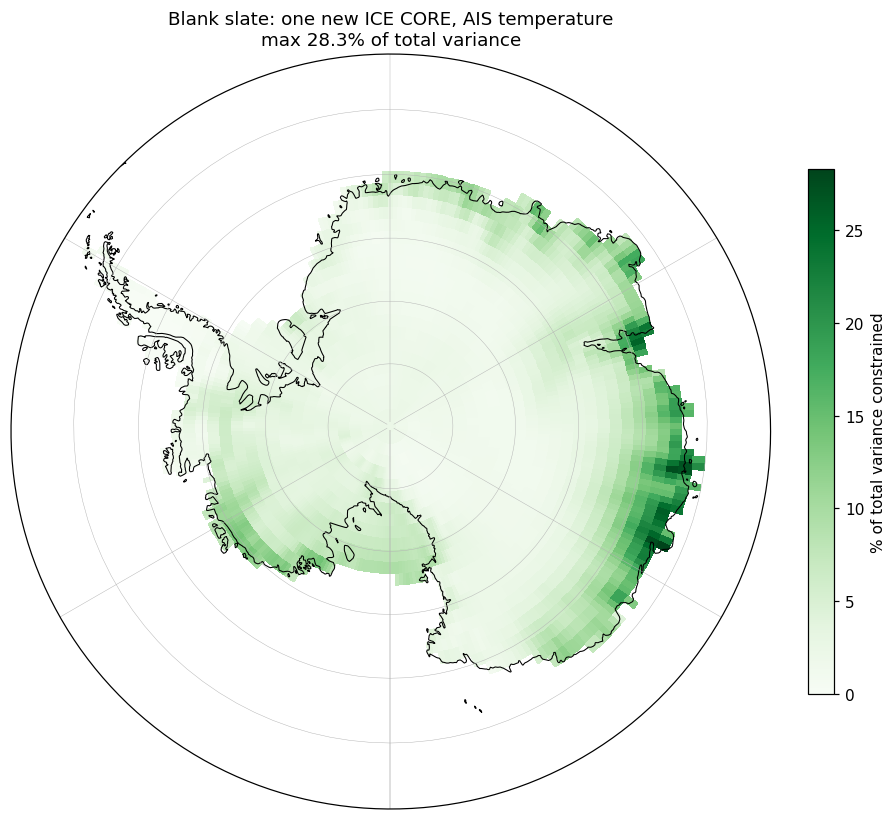

In [13]:
check_ens()
o0 = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
J0 = o0.J0var
pct_blank = 100 * o0.evaluate() / J0
k = int(np.nanargmax(pct_blank))
print(f'blank slate: best single core {pct_blank[k]:.2f}% of TOTAL variance at '
      f'({site_lat[k]:.2f}, {site_lon[k]:.2f}), A = {accum_rate[k]:.0f} mm/yr, '
      f'R = {R_ICE_CORE[k]:.2f} K^2')
fig = plt.figure(figsize=(11, 10)); ax = plt.axes(projection=SP)
field_map(pct_blank, 'Blank slate: one new ICE CORE, AIS temperature\n'
                     f'max {pct_blank[k]:.1f}% of total variance', ax=ax, fig=fig)
plt.show()


AWS network (per_station) constrains 88.82% of AIS variance
best additional ice core: 0.47% at (-74.92, 282.50), A = 672 mm/yr


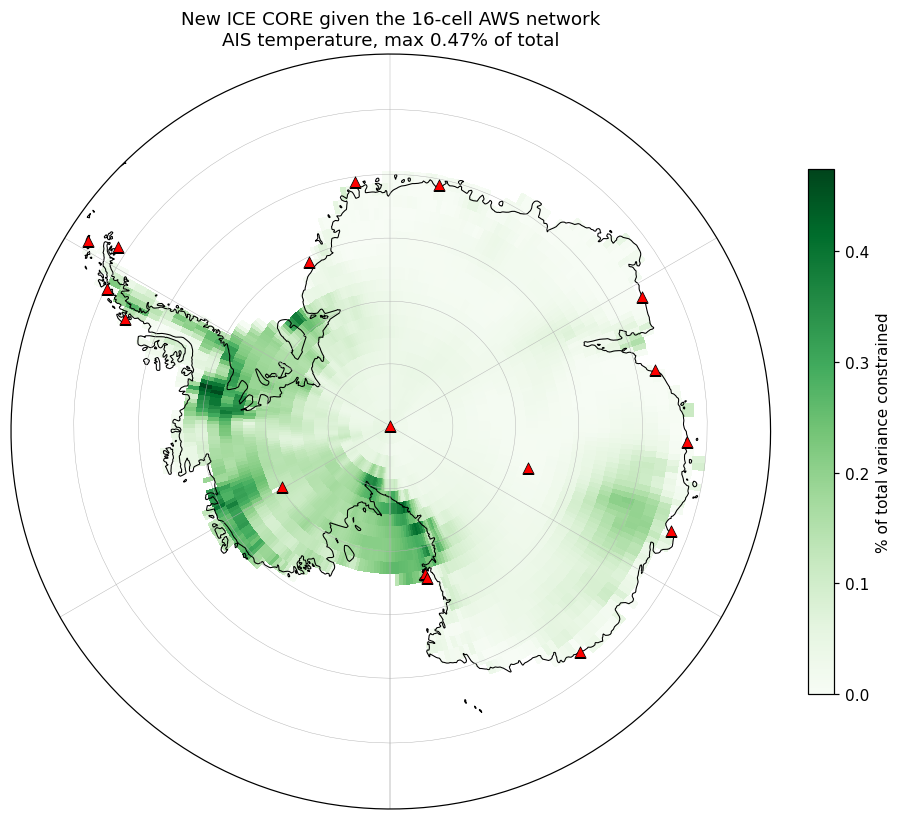

In [14]:
check_ens()
oA = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
for i in AWS_SITES:
    oA.assimilate(int(i), Rval=R_aws(i))
v0 = oA.metric_variance()
pct_core = 100 * oA.evaluate() / J0
k = int(np.nanargmax(pct_core))
print(f'AWS network ({R_AWS_MODE}) constrains {100*(1-v0/J0):.2f}% of AIS variance')
print(f'best additional ice core: {pct_core[k]:.2f}% at '
      f'({site_lat[k]:.2f}, {site_lon[k]:.2f}), A = {accum_rate[k]:.0f} mm/yr')
fig = plt.figure(figsize=(11, 10)); ax = plt.axes(projection=SP)
field_map(pct_core, 'New ICE CORE given the 16-cell AWS network\n'
                    f'AIS temperature, max {pct_core[k]:.2f}% of total',
          ax=ax, fig=fig, show_aws=True)
plt.show()


best new AWS (R=0.2): 2.36% of total at (-78.69, 142.50)


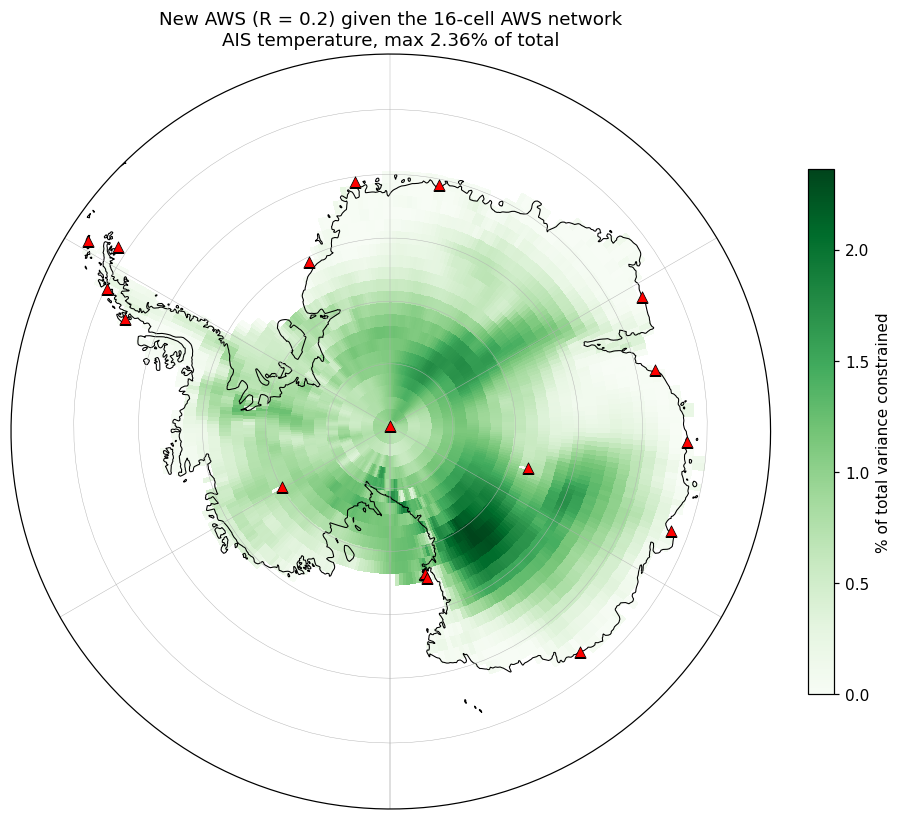

In [15]:
check_ens()
oB = OptimalSensor(J, Ye[:N_POTENTIAL], R_AWS_NEW)
for i in AWS_SITES:
    oB.assimilate(int(i), Rval=R_aws(i))
pct_aws = 100 * oB.evaluate() / J0
k = int(np.nanargmax(pct_aws))
print(f'best new AWS (R={R_AWS_NEW}): {pct_aws[k]:.2f}% of total at '
      f'({site_lat[k]:.2f}, {site_lon[k]:.2f})')
fig = plt.figure(figsize=(11, 10)); ax = plt.axes(projection=SP)
field_map(pct_aws, f'New AWS (R = {R_AWS_NEW}) given the 16-cell AWS network\n'
                   f'AIS temperature, max {pct_aws[k]:.2f}% of total',
          ax=ax, fig=fig, show_aws=True)
plt.show()


  1. East Antarctic Plateau       max  0.65%
  2. Wilkes Land Coast            max  1.05%
  3. Weddell Sea Coast            max 12.80%
  4. Antarctic Peninsula          max 10.05%
  5. WAIS                         max  6.35%
  6. Victoria Land / Ross Sea     max  1.55%
  7. Dronning Maud Land Coast     max  0.92%


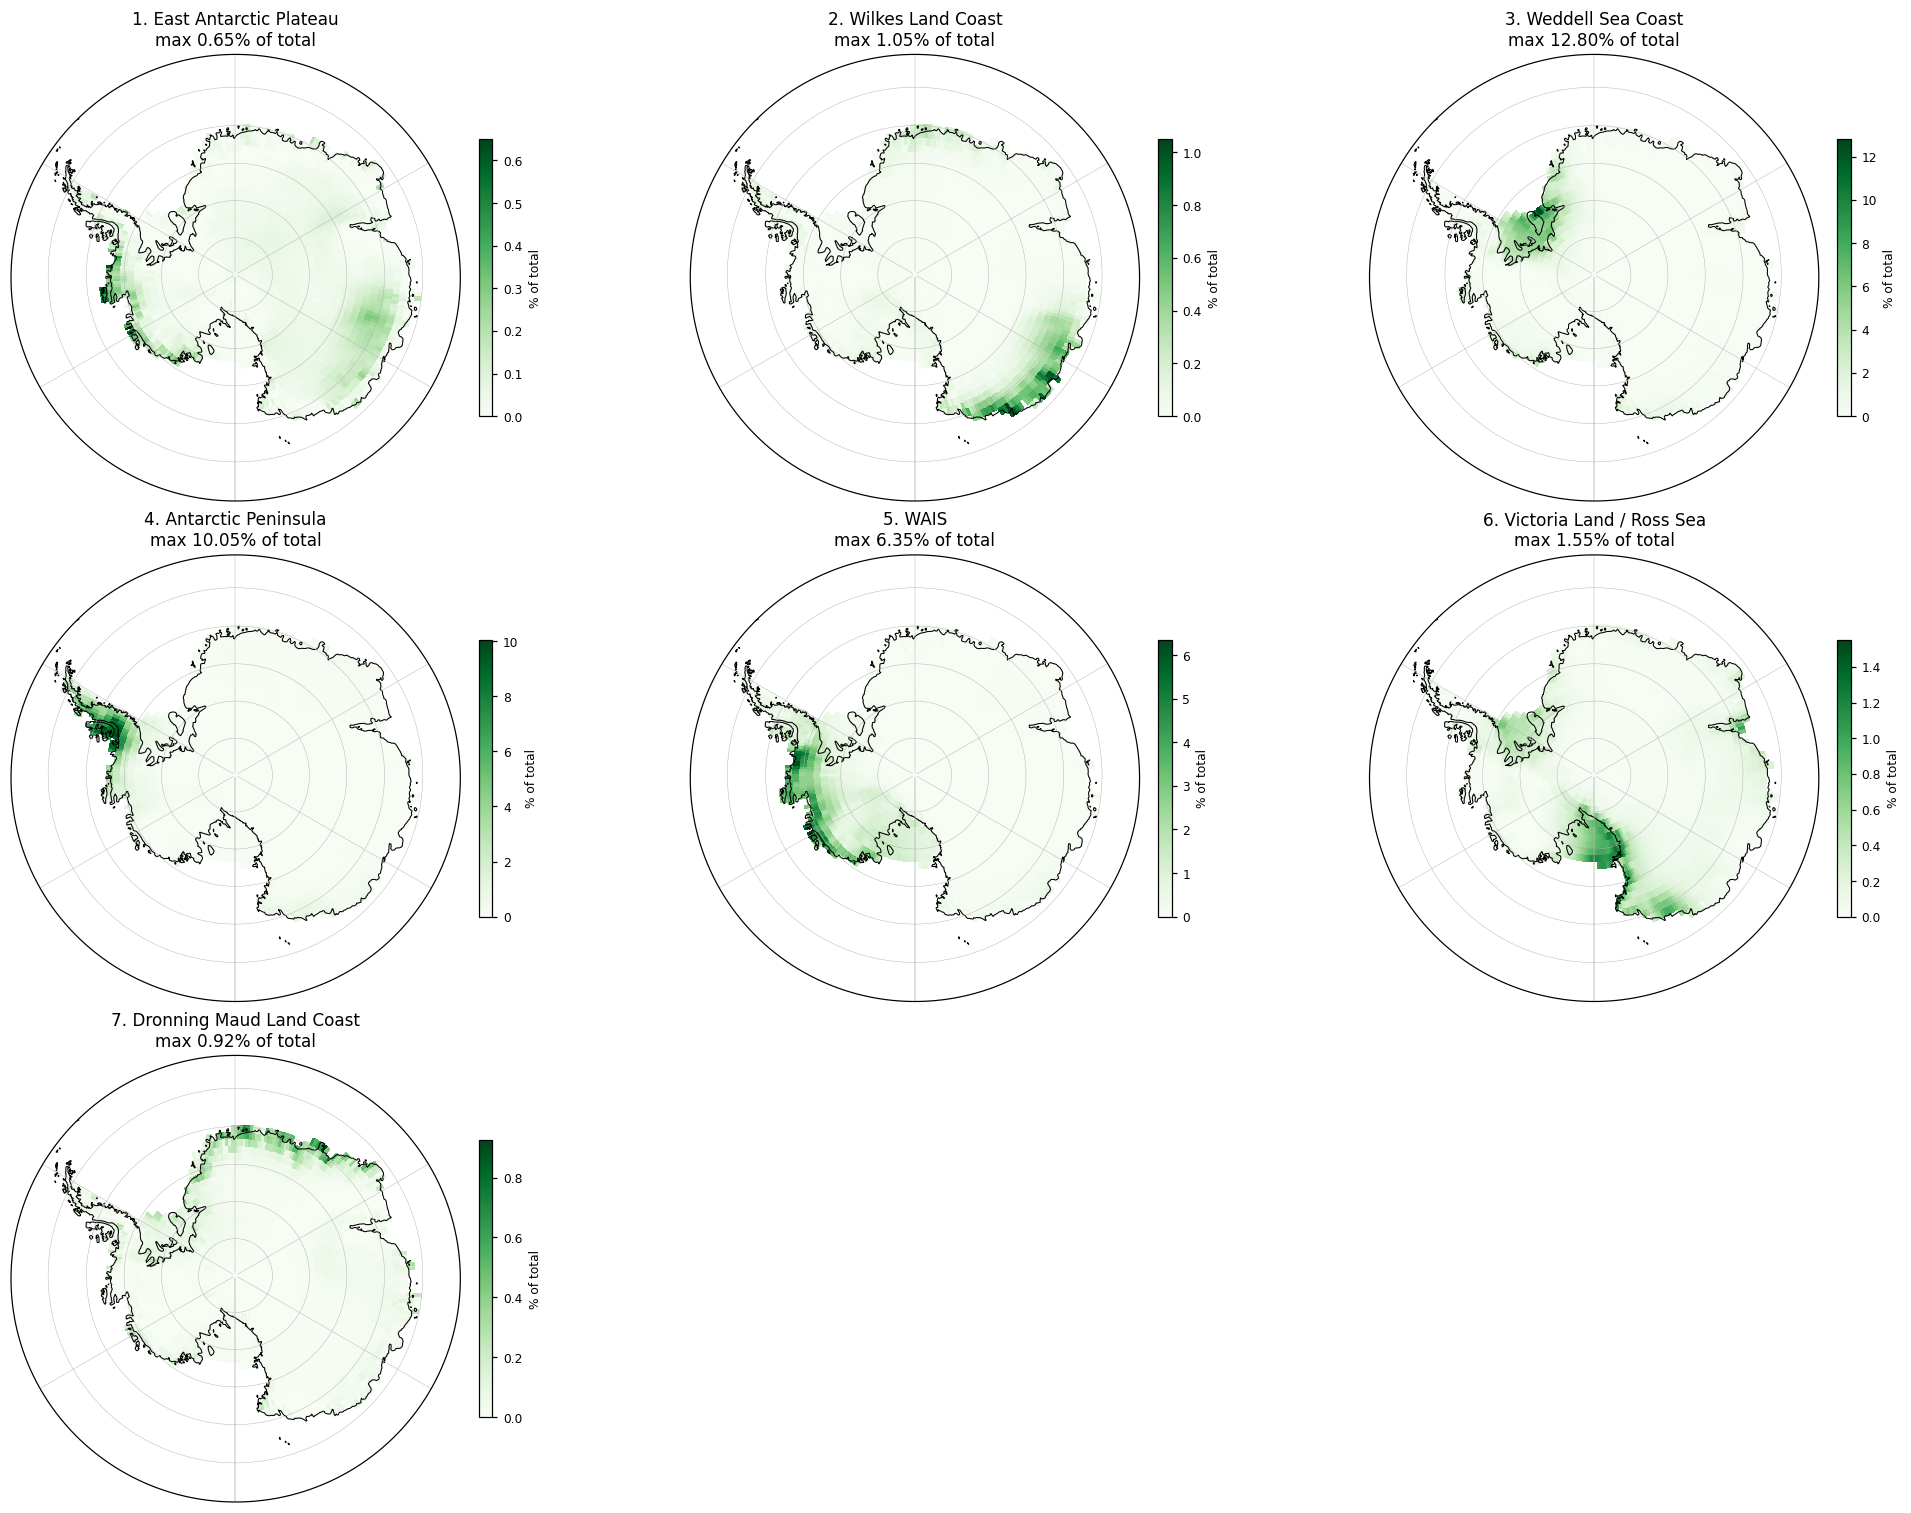

In [16]:
check_ens()
fig = plt.figure(figsize=(19, 14))
for idx, v in enumerate(range(1, 8)):
    Jr = build_metric(Ye, mask=p2k_mask[v])
    ov = OptimalSensor(Jr, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0r = ov.J0var
    for i in AWS_SITES:
        ov.assimilate(int(i), Rval=R_aws(i))
    p = 100 * ov.evaluate() / J0r
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.66 - r_*0.325, 0.29, 0.29], projection=SP)
    sc = field_map(p, f'{v}. {P2K_NAMES[v]}\nmax {np.nanmax(p):.2f}% of total',
                   ax=ax, fig=fig, cb=False, fs=11)
    cb = fig.colorbar(sc, ax=ax, shrink=.62, pad=.03)
    cb.ax.tick_params(labelsize=8); cb.set_label('% of total', fontsize=8)
    print(f'  {v}. {P2K_NAMES[v]:28s} max {np.nanmax(p):5.2f}%')
plt.show()


               core  add_pct  cum_pct
rank                                 
1     Siple Station    0.363   89.184
2        ITASE-00-3    0.179   89.364
3        ITASE-01-5    0.139   89.503
4              RICE    0.118   89.620
5     Bruce Plateau    0.116   89.736


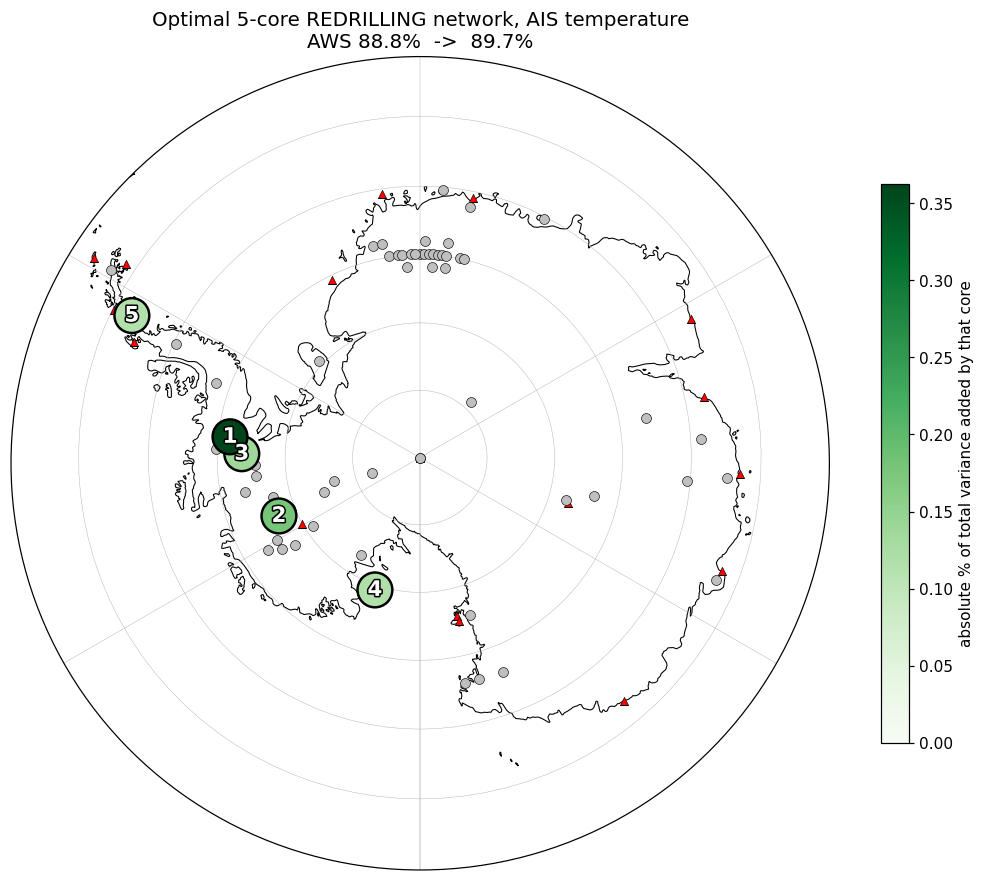

In [17]:
check_ens(); require('core_mask', 'name_of')

def redrill_net(Jm, N):
    """Greedy sequential, restricted to existing core cells, after the AWS net."""
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_aws(i))
    base = 100 * (1 - ob.metric_variance() / J0m)
    st, cum = [], []
    for _ in range(N):
        dv = np.where(np.isfinite(ob.evaluate()), ob.evaluate(), -np.inf)
        dv = np.where(core_mask, dv, -np.inf)
        for k2 in st:
            dv[k2] = -np.inf
        b = int(np.argmax(dv)); ob.assimilate(b)
        st.append(b); cum.append(100 * (1 - ob.metric_variance() / J0m))
    return np.array(st), np.array(cum), base

def draw_net(ax, st, cum, base, title, fs=11, big=300, num=10):
    polar_ax(ax)
    ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=30, c='red',
               edgecolors='k', lw=.4, transform=PL, zorder=2)
    add = np.diff(np.concatenate([[base], cum]))    # absolute % each core adds
    other = [k2 for k2 in CORE_SITES if k2 not in set(st)]
    ax.scatter(site_lon[other], site_lat[other], s=42, c='0.75', edgecolors='k',
               lw=.4, transform=PL, zorder=3)
    o_ = np.arange(len(st))[::-1]
    sc = ax.scatter(site_lon[st][o_], site_lat[st][o_], c=add[o_], s=big,
                    cmap=CMAP, vmin=0, vmax=float(add.max()), edgecolors='k',
                    lw=1.6, transform=PL, zorder=4)
    for rr, k2 in zip(range(len(st), 0, -1), st[::-1]):
        ax.annotate(str(rr), (site_lon[k2], site_lat[k2]),
                    xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                    fontsize=num, fontweight='bold', color='w', zorder=6,
                    path_effects=[pe.withStroke(linewidth=2, foreground='k')])
    ax.set_title(title, fontsize=fs)
    return sc, add

st, cum, base = redrill_net(J, 5)
fig = plt.figure(figsize=(12, 11)); ax = plt.axes(projection=SP)
sc, add = draw_net(ax, st, cum, base,
                   'Optimal 5-core REDRILLING network, AIS temperature\n'
                   f'AWS {base:.1f}%  ->  {cum[-1]:.1f}%', fs=13, big=520, num=14)
cb = fig.colorbar(sc, ax=ax, shrink=.6, pad=.05)
cb.set_label('absolute % of total variance added by that core')
print(pd.DataFrame({'rank': range(1, 6), 'core': [name_of[int(x)] for x in st],
                    'add_pct': add, 'cum_pct': cum}).set_index('rank').round(3).to_string())
plt.show()


                                              core  add_pct  cum_pct
region                     rank                                     
1 East Antarctic Plateau   1               DML S20    0.157   87.695
                           2                   DIV    0.133   87.828
                           3              400th km    0.127   87.955
2 Wilkes Land Coast        1               DML S20    0.300   91.992
                           2              Law Dome    0.233   92.225
                           3         Bruce Plateau    0.122   92.347
3 Weddell Sea Coast        1        Berkner Island    5.797   55.852
                           2     Whitehall Glacier    1.587   57.439
                           3                   THW    0.608   58.047
4 Antarctic Peninsula      1                 Gomez    6.638   75.599
                           2         Bruce Plateau    4.029   79.628
                           3          Dyer Plateau    1.692   81.320
5 WAIS                     1      

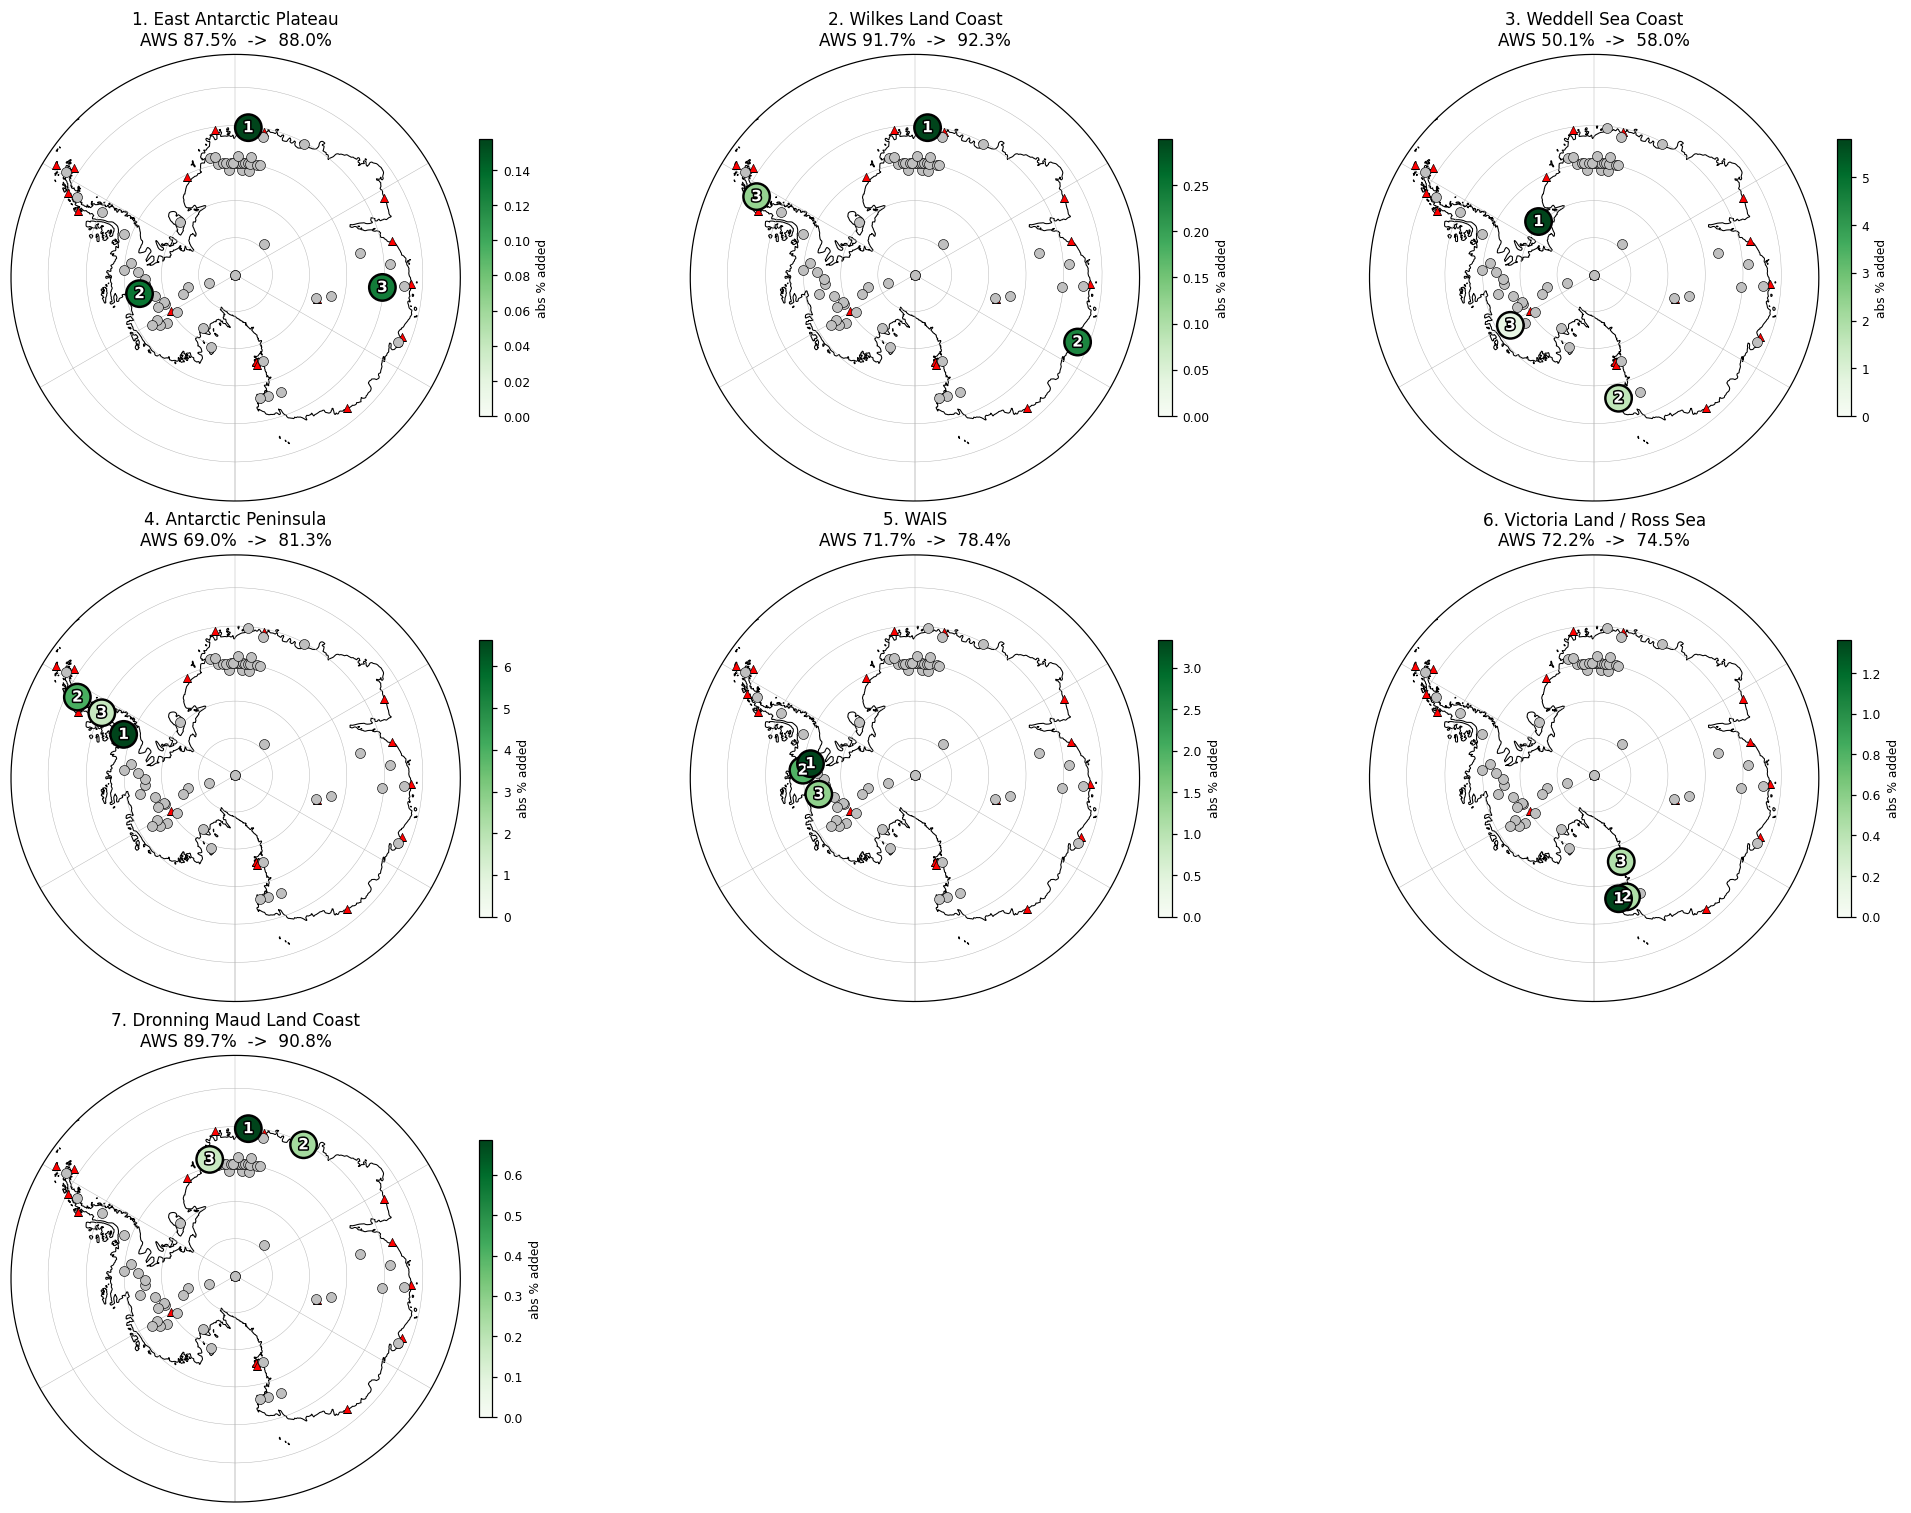

In [18]:
check_ens()
fig = plt.figure(figsize=(19, 14)); rows = []
for idx, v in enumerate(range(1, 8)):
    Jr = build_metric(Ye, mask=p2k_mask[v])
    stv, cumv, basev = redrill_net(Jr, 3)
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.66 - r_*0.325, 0.29, 0.29], projection=SP)
    sc, add = draw_net(ax, stv, cumv, basev,
                       f'{v}. {P2K_NAMES[v]}\nAWS {basev:.1f}%  ->  {cumv[-1]:.1f}%')
    cb = fig.colorbar(sc, ax=ax, shrink=.62, pad=.03)
    cb.ax.tick_params(labelsize=8); cb.set_label('abs % added', fontsize=8)
    for rr, (k2, a) in enumerate(zip(stv, add), 1):
        rows.append(dict(region=f'{v} {P2K_NAMES[v]}', rank=rr,
                         core=name_of[int(k2)], add_pct=a, cum_pct=cumv[rr-1]))
print(pd.DataFrame(rows).set_index(['region', 'rank']).round(3).to_string())
plt.show()


In [19]:
check_ens()
rows = []
for lbl, Jm in ([('AIS-wide', J)] +
                [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]))
                 for v in range(1, 8)]):
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_aws(i))
    v0m = ob.metric_variance()
    rows.append(dict(metric=lbl, var=J0m, sd=np.sqrt(J0m), remaining=v0m,
                     resid_sd=np.sqrt(v0m), constrained_pct=100*(1 - v0m/J0m)))
print(f'{len(AWS_SITES)}-cell READER AWS network, R_AWS_MODE={R_AWS_MODE}, '
      f'{nM} ensemble members\n')
print(pd.DataFrame(rows).round(4).to_string(index=False))


16-cell READER AWS network, R_AWS_MODE=per_station, 160 ensemble members

                     metric    var     sd  remaining  resid_sd  constrained_pct
                   AIS-wide 0.3183 0.5642     0.0356    0.1886          88.8218
  1. East Antarctic Plateau 0.4244 0.6514     0.0529    0.2300          87.5374
       2. Wilkes Land Coast 0.4651 0.6820     0.0386    0.1966          91.6923
       3. Weddell Sea Coast 0.6036 0.7769     0.3015    0.5491          50.0553
     4. Antarctic Peninsula 0.7379 0.8590     0.2290    0.4786          68.9612
                    5. WAIS 0.5494 0.7412     0.1557    0.3946          71.6580
6. Victoria Land / Ross Sea 0.4917 0.7012     0.1366    0.3695          72.2285
7. Dronning Maud Land Coast 0.3197 0.5655     0.0330    0.1818          89.6643


threshold 90% of total variance, nM=160, DOF=159, network capped at 79 observations

                     metric  aws_base  n  reached  n80  n85  capped  dof_pct
                   AIS-wide     88.82  4    90.27    1    1   False    12.58
  1. East Antarctic Plateau     87.54 10    90.02    1    1   False    16.35
       2. Wilkes Land Coast     91.69  1    92.74    1    1   False    10.69
       3. Weddell Sea Coast     50.06 30    90.06    6   12   False    28.93
     4. Antarctic Peninsula     68.96  5    90.73    2    3   False    13.21
                    5. WAIS     71.66 10    90.02    2    4   False    16.35
6. Victoria Land / Ross Sea     72.23 46    90.06    8   19   False    38.99
7. Dronning Maud Land Coast     89.66  1    90.59    1    1   False    10.69


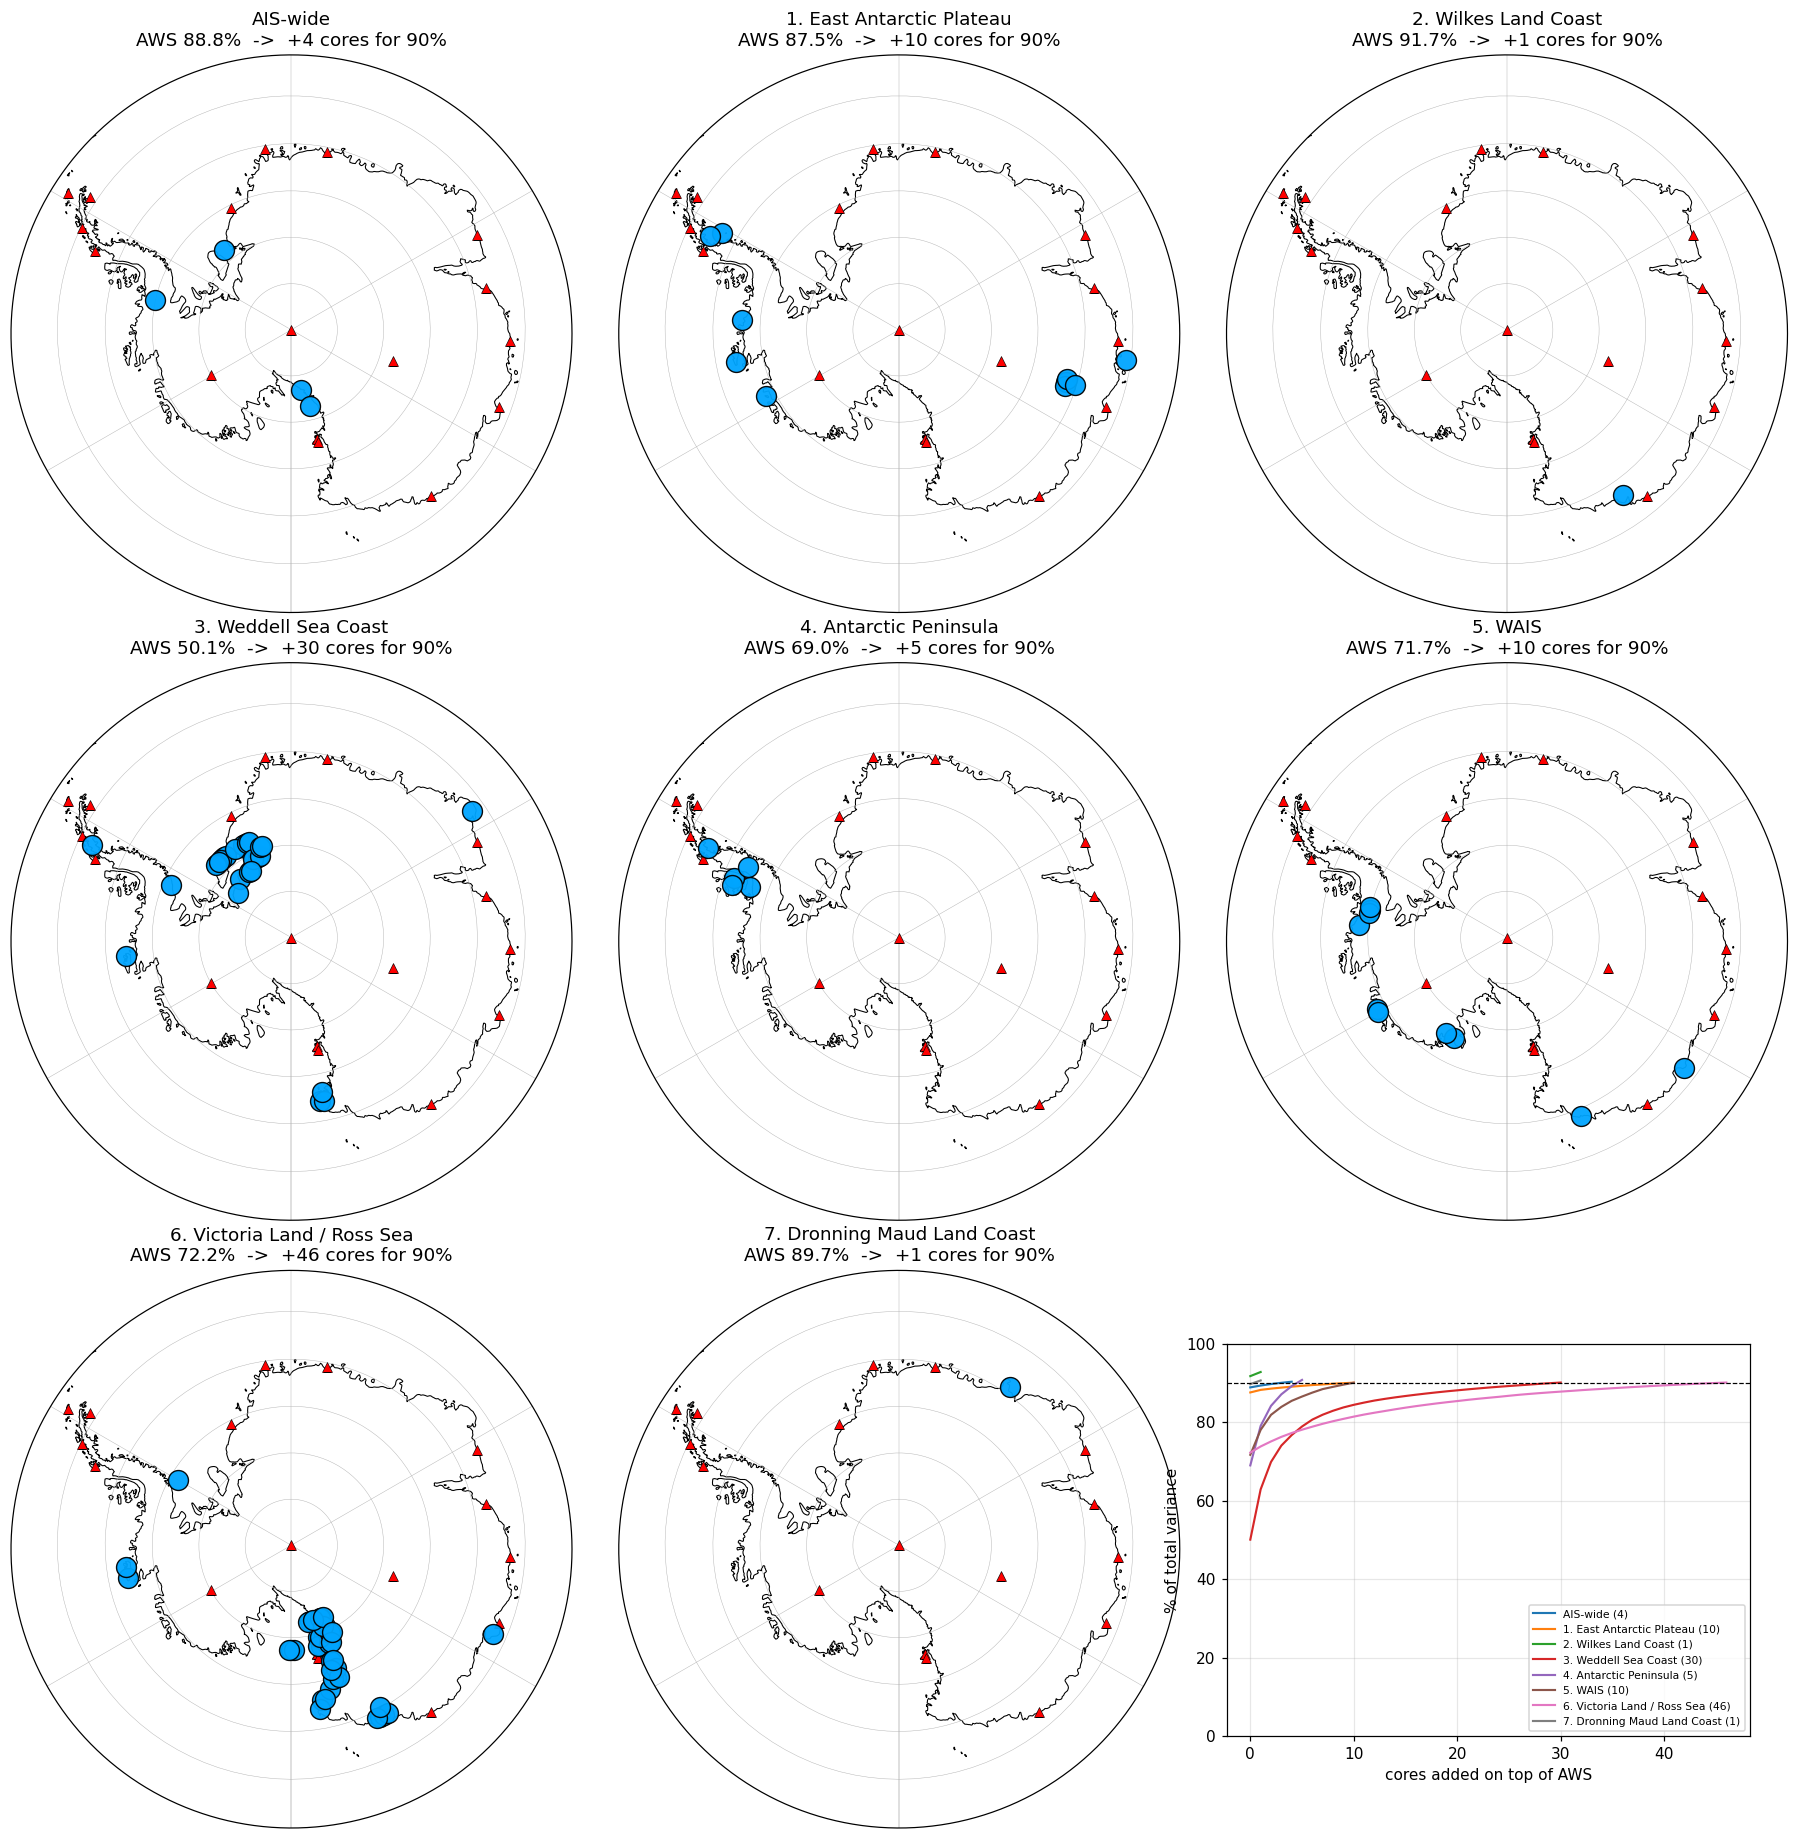

In [24]:
check_ens()
THRESH, NMAX, DOF_LIMIT = 0.9, 400, 0.50
CORE_COLOR = '#00A5FF'
DOF_MAX = int(DOF_LIMIT * (nM - 1))
print(f'threshold {100*THRESH:.0f}% of total variance, nM={nM}, DOF={nM-1}, '
      f'network capped at {DOF_MAX} observations\n')

mets = ([('AIS-wide', J)] +
        [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]))
         for v in range(1, 8)])
res, rows = {}, []
for lbl, Jm in mets:
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_aws(i))
    base = 100 * (1 - ob.metric_variance() / J0m)
    st2, cum2, capped = [], [], False
    for _ in range(NMAX):
        if len(AWS_SITES) + len(st2) >= DOF_MAX:
            capped = True; break
        dv = np.where(np.isfinite(ob.evaluate()), ob.evaluate(), -np.inf)
        for k2 in st2:
            dv[k2] = -np.inf
        b = int(np.argmax(dv))
        if dv[b] <= 0:
            break
        vv = ob.assimilate(b); st2.append(b)
        cum2.append(100 * (1 - vv / J0m))
        if cum2[-1] >= 100 * THRESH:
            break
    st2, cum2 = np.array(st2), np.array(cum2)
    res[lbl] = (st2, cum2, base, capped)
    hit = lambda p: (int(np.argmax(cum2 >= p)) + 1) if (cum2 >= p).any() else -1
    rows.append(dict(metric=lbl, aws_base=base, n=len(st2), reached=cum2[-1],
                     n80=hit(80), n85=hit(85), capped=capped,
                     dof_pct=100*(len(AWS_SITES)+len(st2))/(nM-1)))
print(pd.DataFrame(rows).round(2).to_string(index=False))

fig = plt.figure(figsize=(17, 17))
for idx, (lbl, _) in enumerate(mets):
    st2, cum2, base, capped = res[lbl]
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.30, 0.30], projection=SP)
    polar_ax(ax)
    ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=42, c='red', edgecolors='k',
               lw=.4, transform=PL, zorder=2)
    ax.scatter(site_lon[st2], site_lat[st2], s=170, c=CORE_COLOR, edgecolors='k',
               lw=.9, transform=PL, zorder=3, alpha=.95)
    tail = f'{100*THRESH:.0f}%' if not capped else f'DOF cap, {cum2[-1]:.1f}%'
    ax.set_title(f'{lbl}\nAWS {base:.1f}%  ->  +{len(st2)} cores for {tail}',
                 fontsize=12)

ax = fig.add_axes([0.02 + 2*0.325, 0.68 - 2*0.325 + 0.05, 0.28, 0.21])
for lbl, _ in mets:
    st2, cum2, base, capped = res[lbl]
    ax.plot(np.arange(0, len(cum2)+1), np.concatenate([[base], cum2]), lw=1.4,
            label=f'{lbl} ({len(st2)}{"+" if capped else ""})')
ax.axhline(100*THRESH, color='k', ls='--', lw=.8)
ax.set_xlabel('cores added on top of AWS')
ax.set_ylabel('% of total variance'); ax.set_ylim(0, 100)
ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=.3)
plt.show()


threshold 80% of total variance, nM=160, DOF=159, network capped at 79 observations

                     metric  aws_base  n  reached  n80  n85  capped  dof_pct
                   AIS-wide     88.82  1    89.30    1    1   False    10.69
  1. East Antarctic Plateau     87.54  1    88.19    1    1   False    10.69
       2. Wilkes Land Coast     91.69  1    92.74    1    1   False    10.69
       3. Weddell Sea Coast     50.06  6    80.63    6   -1   False    13.84
     4. Antarctic Peninsula     68.96  2    84.12    2   -1   False    11.32
                    5. WAIS     71.66  2    81.83    2   -1   False    11.32
6. Victoria Land / Ross Sea     72.23  8    80.21    8   -1   False    15.09
7. Dronning Maud Land Coast     89.66  1    90.59    1    1   False    10.69


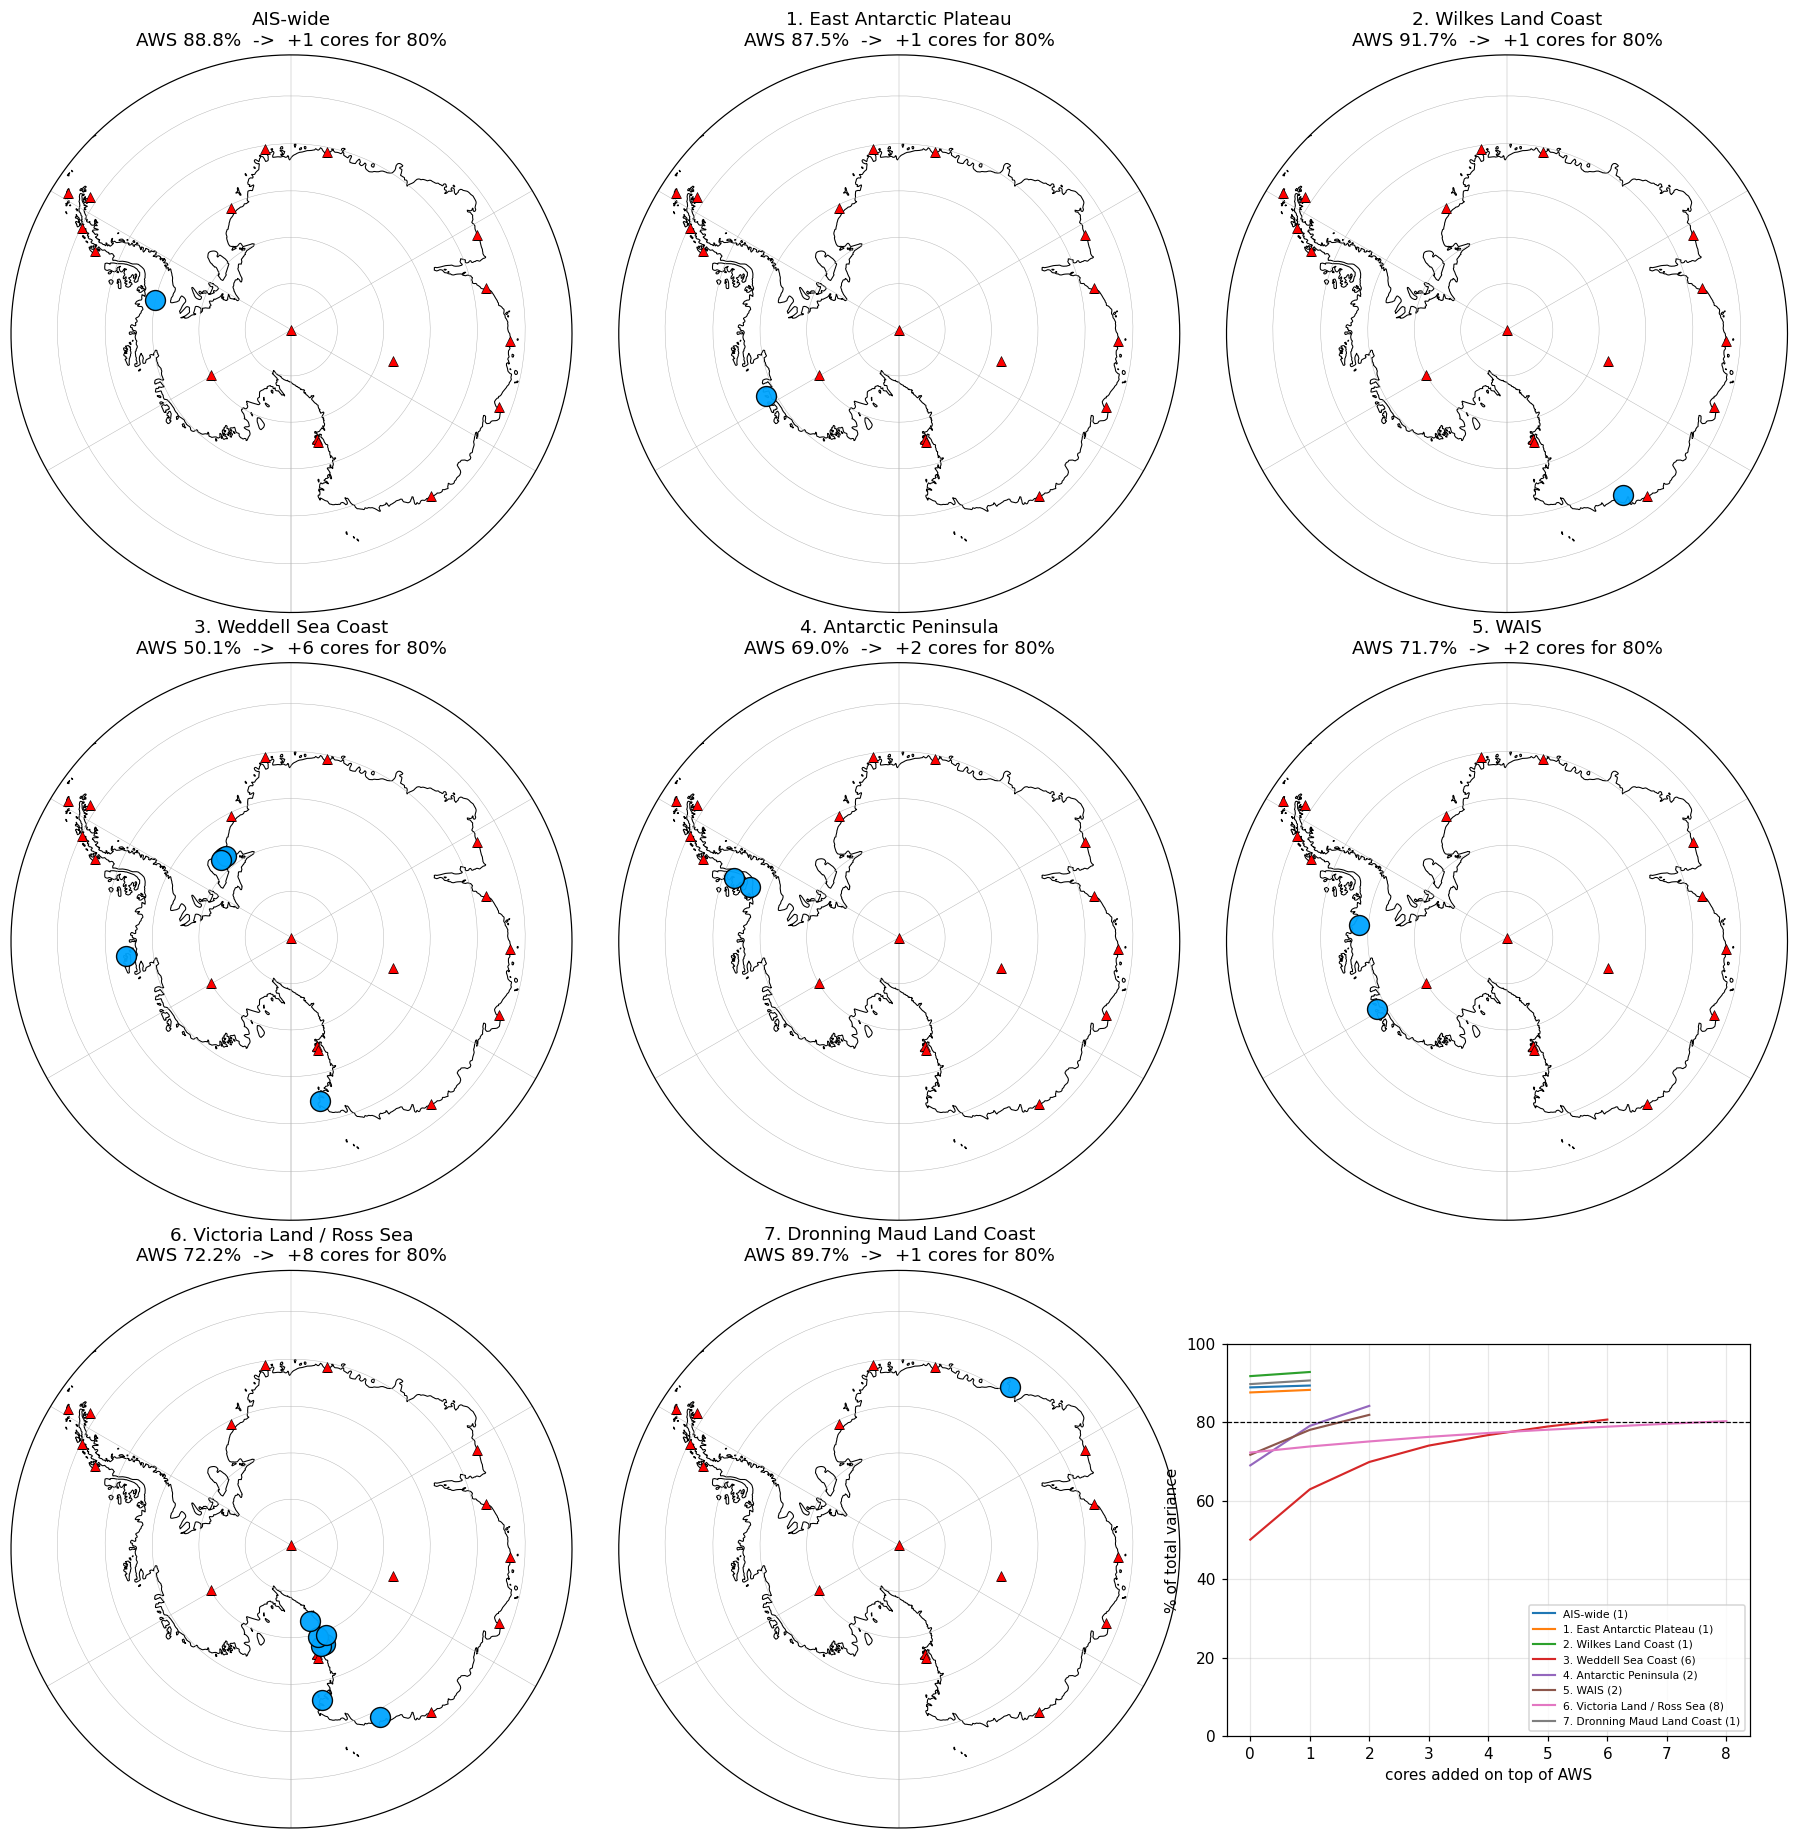

In [26]:
check_ens()
THRESH, NMAX, DOF_LIMIT = 0.8, 400, 0.50
CORE_COLOR = '#00A5FF'
DOF_MAX = int(DOF_LIMIT * (nM - 1))
print(f'threshold {100*THRESH:.0f}% of total variance, nM={nM}, DOF={nM-1}, '
      f'network capped at {DOF_MAX} observations\n')

mets = ([('AIS-wide', J)] +
        [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]))
         for v in range(1, 8)])
res, rows = {}, []
for lbl, Jm in mets:
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0m = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_aws(i))
    base = 100 * (1 - ob.metric_variance() / J0m)
    st2, cum2, capped = [], [], False
    for _ in range(NMAX):
        if len(AWS_SITES) + len(st2) >= DOF_MAX:
            capped = True; break
        dv = np.where(np.isfinite(ob.evaluate()), ob.evaluate(), -np.inf)
        for k2 in st2:
            dv[k2] = -np.inf
        b = int(np.argmax(dv))
        if dv[b] <= 0:
            break
        vv = ob.assimilate(b); st2.append(b)
        cum2.append(100 * (1 - vv / J0m))
        if cum2[-1] >= 100 * THRESH:
            break
    st2, cum2 = np.array(st2), np.array(cum2)
    res[lbl] = (st2, cum2, base, capped)
    hit = lambda p: (int(np.argmax(cum2 >= p)) + 1) if (cum2 >= p).any() else -1
    rows.append(dict(metric=lbl, aws_base=base, n=len(st2), reached=cum2[-1],
                     n80=hit(80), n85=hit(85), capped=capped,
                     dof_pct=100*(len(AWS_SITES)+len(st2))/(nM-1)))
print(pd.DataFrame(rows).round(2).to_string(index=False))

fig = plt.figure(figsize=(17, 17))
for idx, (lbl, _) in enumerate(mets):
    st2, cum2, base, capped = res[lbl]
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.30, 0.30], projection=SP)
    polar_ax(ax)
    ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=42, c='red', edgecolors='k',
               lw=.4, transform=PL, zorder=2)
    ax.scatter(site_lon[st2], site_lat[st2], s=170, c=CORE_COLOR, edgecolors='k',
               lw=.9, transform=PL, zorder=3, alpha=.95)
    tail = f'{100*THRESH:.0f}%' if not capped else f'DOF cap, {cum2[-1]:.1f}%'
    ax.set_title(f'{lbl}\nAWS {base:.1f}%  ->  +{len(st2)} cores for {tail}',
                 fontsize=12)

ax = fig.add_axes([0.02 + 2*0.325, 0.68 - 2*0.325 + 0.05, 0.28, 0.21])
for lbl, _ in mets:
    st2, cum2, base, capped = res[lbl]
    ax.plot(np.arange(0, len(cum2)+1), np.concatenate([[base], cum2]), lw=1.4,
            label=f'{lbl} ({len(st2)}{"+" if capped else ""})')
ax.axhline(100*THRESH, color='k', ls='--', lw=.8)
ax.set_xlabel('cores added on top of AWS')
ax.set_ylabel('% of total variance'); ax.set_ylim(0, 100)
ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=.3)
plt.show()
